<a href="https://colab.research.google.com/github/Mbogho64/Mbogho-s-week-3-course-project/blob/main/Week_3_Assignment_%7C_Designing_my_machine_learning_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project problem
Mine and quarry slopes can become unstable due to interacting geotechnical, geometric and groundwater conditions. Conventional monitoring may not adequately capture these interactions. This project investigates whether machine learning can use slope and geotechnical parameters to predict slope instability and support early warning of potential slope failure.

# Intended AI/ML outcome
The intended outcome is a chine learning model that predicts whether a mine/quarry slope is stable or potentially unstable based on its geotechnical, geometric, groundwater and reinforcement conditions.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving slope_stability_dataset.csv to slope_stability_dataset (2).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("slope_stability_dataset.csv")
df.head()
df.head(10)

,Unit Weight (kN/m³),Cohesion (kPa),Internal Friction Angle (°),Slope Angle (°),Slope Height (m),Pore Water Pressure Ratio,Reinforcement Type,Reinforcement Numeric,Factor of Safety (FS)
0,18.745401,21.813837,38.249958,41.907228,18.451042,0.847237,Drainage,3,2.613692
1,24.507143,19.981044,24.612800,32.964623,9.266800,0.494517,Geosynthetics,2,2.241626
2,22.319939,12.926926,28.665992,58.224926,10.686165,0.195466,Retaining Wall,0,1.568244
3,20.986585,32.327000,36.582016,20.948923,13.130201,0.736642,Drainage,3,3.000000
4,16.560186,26.448087,32.052234,39.392821,14.164400,0.418678,Soil Nailing,1,3.000000
5,16.559945,43.956545,38.464276,45.010501,15.901781,0.594627,Geosynthetics,2,3.000000
6,15.580836,6.444931,44.030198,51.278224,16.495701,0.107265,Geosynthetics,2,1.545751
7,23.661761,33.974057,22.913667,30.348552,25.507236,0.631584,Retaining Wall,0,3.000000
8,21.011150,39.332700,37.739193,44.346095,27.930794,0.373550,Soil Nailing,1,3.000000
9,22.080726,39.176896,25.758604,25.160074,18.899564,0.334190,Soil Nailing,1,3.000000


The table above shows a sample of the dataset used for the project. Each row represents an observation, while the columns contain variables that may be useful for predicting slope instability.

In [ ]:
df.shape

(10000, 9)

The dataset contains 10,000 observations and 9variables describing slope material properties, slope geometry, pore water conditions, reinforcement and Factor of Safety

In [ ]:
df.columns

Index(['Unit Weight (kN/m³)', 'Cohesion (kPa)', 'Internal Friction Angle (°)',
       'Slope Angle (°)', 'Slope Height (m)', 'Pore Water Pressure Ratio',
       'Reinforcement Type', 'Reinforcement Numeric', 'Factor of Safety (FS)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unit Weight (kN/m³)          10000 non-null  float64
 1   Cohesion (kPa)               10000 non-null  float64
 2   Internal Friction Angle (°)  10000 non-null  float64
 3   Slope Angle (°)              10000 non-null  float64
 4   Slope Height (m)             10000 non-null  float64
 5   Pore Water Pressure Ratio    10000 non-null  float64
 6   Reinforcement Type           10000 non-null  object 
 7   Reinforcement Numeric        10000 non-null  int64  
 8   Factor of Safety (FS)        10000 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 703.3+ KB


In [ ]:
df.describe()

,Unit Weight (kN/m³),Cohesion (kPa),Internal Friction Angle (°),Slope Angle (°),Slope Height (m),Pore Water Pressure Ratio,Reinforcement Numeric,Factor of Safety (FS)
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,19.941596,27.703844,32.501260,34.935669,27.358871,0.503145,1.494300,2.545083
std,2.876301,13.018255,7.169344,14.449730,13.017788,0.288341,1.120399,0.659996
min,15.000116,5.007099,20.001203,10.000277,5.000753,0.000008,0.000000,0.500000
25%,17.463289,16.427561,26.343698,22.342862,15.992250,0.256956,0.000000,2.125824
50%,19.925286,27.765355,32.551702,35.001512,27.217274,0.506090,1.000000,3.000000
75%,22.400063,39.041565,38.616846,47.355813,38.771467,0.753446,3.000000,3.000000
max,24.997177,49.996617,44.997524,59.989469,49.998747,0.999940,3.000000,3.000000


In [ ]:
df.isnull().sum()

,0
Unit Weight (kN/m³),0
Cohesion (kPa),0
Internal Friction Angle (°),0
Slope Angle (°),0
Slope Height (m),0
Pore Water Pressure Ratio,0
Reinforcement Type,0
Reinforcement Numeric,0
Factor of Safety (FS),0


The dataset contains numerical geotechnical and slope parameters together with reinforcement information and Factor of Safety. No missing values were identified.

The potantial input features are:
## Geotechnical features


*   Unit weight
*   Cohesion
*   Internal friction angle
## Geometric features


*   Slope angle
*   Slope height
## Hydrogeological feature


*   Power water pressure ratio
## Stabilization feature


*   Reinforcement type










In [ ]:
import numpy as np

df["Stability"] = np.where(
    df["Factor of Safety (FS)"] < 1.0,
    "Unstable",
    "Stable"
)

In [ ]:
df[["Factor of Safety (FS)", "Stability"]].head(10)

,Factor of Safety (FS),Stability
0,2.613692,Stable
1,2.241626,Stable
2,1.568244,Stable
3,3.000000,Stable
4,3.000000,Stable
5,3.000000,Stable
6,1.545751,Stable
7,3.000000,Stable
8,3.000000,Stable
9,3.000000,Stable


In [ ]:
df["Stability"].value_counts()

,count
Stability,
Stable,9705
Unstable,295


In [ ]:
df["Stability"].value_counts(normalize=True)

,proportion
Stability,
Stable,0.9705
Unstable,0.0295


In [ ]:
features = [
    "Unit Weight",
    "Cohesion",
    "Internal Friction Angle",
    "Slope Angle",
    "Slope Height",
    "Power Water Pressure Ratio",
    "Reinforcement Numeric"
]

In [ ]:
correct_features = [
    "Unit Weight (kN/m³)",
    "Cohesion (kPa)",
    "Internal Friction Angle (°)",
    "Slope Angle (°)",
    "Slope Height (m)",
    "Pore Water Pressure Ratio",
    "Reinforcement Numeric"
]

x = df[correct_features]
y = df["Stability"]

## Features and target
The input features represent the principal geotechnical, geometric, groundwater and reinforcement conditions available in the dataset. The target variable, Stability, is derived from the Factor of Safety, wit FS values below 1.0 classified as unstable and values equal to or greater than 1.0 classified as stable

My dataset contains both:


*   Reinforcement type
*   Reinforcement numeric
For the first model, I will use Reinforcement numeric because it is already encoded numerically.



Inspecting the reinforcement categories using:

In [ ]:
df["Reinforcement Type"].value_counts()

,count
Reinforcement Type,
Soil Nailing,2532
Retaining Wall,2517
Drainage,2509
Geosynthetics,2442


Therefore, splitting my data, it follows that:

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Selecting my first ML model:

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

Therefore, making predictions, it follows that:

In [ ]:
y_pred = model.predict(x_test)

Evaluating the model therefore, it follows that:

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.99
              precision    recall  f1-score   support

      Stable       0.99      1.00      0.99      1941
    Unstable       0.98      0.68      0.80        59

    accuracy                           0.99      2000
   macro avg       0.98      0.84      0.90      2000
weighted avg       0.99      0.99      0.99      2000



To identify important features:

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=x_train.columns
)

importance.sort_values(ascending=False)

,0
Cohesion (kPa),0.500144
Internal Friction Angle (°),0.184995
Slope Angle (°),0.109834
Pore Water Pressure Ratio,0.095137
Slope Height (m),0.049657
Unit Weight (kN/m³),0.046428
Reinforcement Numeric,0.013804


Therefore, visualizing it, it follows that:

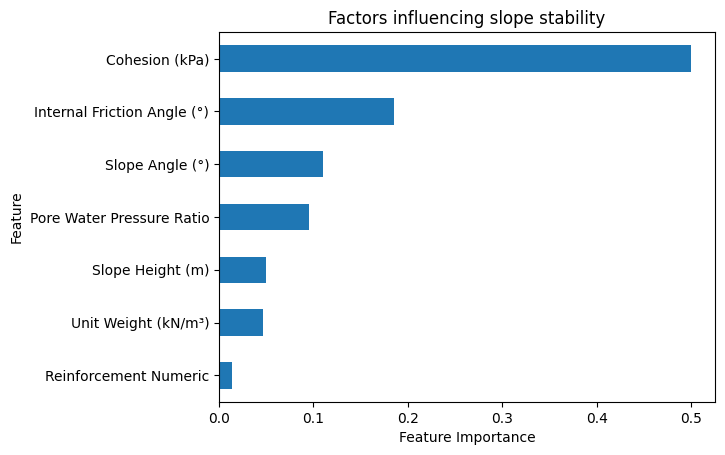

In [ ]:
importance.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Factors influencing slope stability")
plt.show()

```mermaid
graph TD
    A[Slope Stability Dataset] --> B[Data Inspection]
    B --> C[Data Preparation]
    C --> D[Select Geotechnical, Geometric,<br>Groundwater & Reinforcement Features]
    D --> E[Calculate Stability from FS]
    E --> F{Stable / Unstable?}
    F --> G[Train-Test Split]
    G --> H[Random Forest Classifier]
    H --> I[Slope Stability Prediction]
    I --> J[Model Evaluation]
    J --> K[Potential Early-Warning System]

    %% Styling to make it look clean
    style A fill:#D5E8D4,stroke:#82B366,stroke-width:2px
    style F fill:#FFF2CC,stroke:#D6B656,stroke-width:2px
    style H fill:#F8CECC,stroke:#B85450,stroke-width:2px
    style K fill:#DAE8FC,stroke:#6C8EBF,stroke-width:2px
```

The proposed workflow uses geotechnical, geometric, pore water and reinforcement parameters as model inputs. Factor of Safety is used to derive the stability classification. The dataset is divided into training and testing subsets, after which a Random Forest classifier is trained to distinguish stable from unstable slope conditions. The model is evaluated using unseen test data, with particular attention to its ability to identify unstable conditions. The resulting model represents a preliminary framework for an AI/ML-based slope instability early warning system.

This project applies machine learning to the prediction of mine and quarry slope instability. The available dataset provides geotechnical, geometric, pore water and reinforcement parameters that can be used to classify slope conditions as stable or unstable. The developed model will demonstrate whether these parameters can be used to identify patterns associated with potential slope instability and provide a foundation for a future early warning system using real time mine monitoring data.